In [1]:
import os
import json
import random
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display
from scipy.special import expit

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB
from sklearn.neighbors import NearestNeighbors

# Load Step 1/2 artifacts
### 1.1 Paths

In [2]:
random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)

step1_dir = Path("./results_step1")
step2_dir = Path("./results_step2")

print("Step 4 setup complete.")
print("Step 1 dir:", step1_dir)
print("Step 2 dir:", step2_dir)

Step 4 setup complete.
Step 1 dir: results_step1
Step 2 dir: results_step2


### 1.2 Required files

In [3]:
required_step1_files = [
    "train_pairs.parquet",
    "validation_pairs.parquet",
    "test_pairs.parquet",
    "step1_config.json",
]

required_step2_files = [
    "user_embeddings_p_u.npy",
    "item_embeddings_q_i.npy",
    "item_bias.npy",
    "user_index_mapping.parquet",
    "item_index_mapping.parquet",
    "final_step2_config.json",
]

missing_step1 = [
    filename for filename in required_step1_files
    if not (step1_dir / filename).exists()
]

missing_step2 = [
    filename for filename in required_step2_files
    if not (step2_dir / filename).exists()
]

if missing_step1:
    raise FileNotFoundError(f"Missing Step 1 files: {missing_step1}")

if missing_step2:
    raise FileNotFoundError(f"Missing Step 2 files: {missing_step2}")

print("All required files exist.")

All required files exist.


### 1.3 Load data, embeddings, and mappings

In [4]:
train_pairs = pd.read_parquet(step1_dir / "train_pairs.parquet")
val_pairs = pd.read_parquet(step1_dir / "validation_pairs.parquet")
test_pairs = pd.read_parquet(step1_dir / "test_pairs.parquet")

with open(step1_dir / "step1_config.json", "r") as f:
    step1_config = json.load(f)

with open(step2_dir / "final_step2_config.json", "r") as f:
    step2_config = json.load(f)

user_embeddings = np.load(step2_dir / "user_embeddings_p_u.npy").astype(np.float32)
item_embeddings = np.load(step2_dir / "item_embeddings_q_i.npy").astype(np.float32)
item_bias = np.load(step2_dir / "item_bias.npy").reshape(-1).astype(np.float32)

user_mapping = pd.read_parquet(step2_dir / "user_index_mapping.parquet")
item_mapping = pd.read_parquet(step2_dir / "item_index_mapping.parquet")

print("Loaded Step 1 and Step 2 artifacts.")

Loaded Step 1 and Step 2 artifacts.


### 1.4 Standardize pairwise columns

In [5]:
def standardize_pair_columns(pair_df):
    df = pair_df.copy()

    rename_map = {
        "preferred_item": "pos_item",
        "less_preferred_item": "neg_item",
        "rating_preferred": "rating_pos",
        "rating_less_preferred": "rating_neg",
        "timestamp_preferred": "timestamp_pos",
        "timestamp_less_preferred": "timestamp_neg",
    }

    df = df.rename(
        columns={
            old_name: new_name
            for old_name, new_name in rename_map.items()
            if old_name in df.columns
        }
    )

    required_columns = [
        "user_id",
        "pos_item",
        "neg_item",
        "rating_pos",
        "rating_neg",
        "rating_diff",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    return df


train_pairs = standardize_pair_columns(train_pairs)
val_pairs = standardize_pair_columns(val_pairs)
test_pairs = standardize_pair_columns(test_pairs)

display(train_pairs.head())

,user_id,pos_item,neg_item,rating_pos,rating_neg,rating_diff,timestamp_pos,timestamp_neg
0,1,1022,2340,5,3,2,978300055,978300103
1,1,1270,2340,5,3,2,978300055,978300103
2,1,1022,720,5,3,2,978300055,978300760
3,1,1270,720,5,3,2,978300055,978300760
4,1,1022,914,5,3,2,978300055,978301968


### 1.5 Add user/item indices

In [6]:
user_to_idx = dict(zip(user_mapping["user_id"], user_mapping["user_idx"]))
item_to_idx = dict(zip(item_mapping["movie_id"], item_mapping["item_idx"]))


def add_pair_indices(pair_df, split_name):
    df = pair_df.copy()

    df["user_idx"] = df["user_id"].map(user_to_idx)
    df["pos_item_idx"] = df["pos_item"].map(item_to_idx)
    df["neg_item_idx"] = df["neg_item"].map(item_to_idx)

    missing_user = int(df["user_idx"].isna().sum())
    missing_pos_item = int(df["pos_item_idx"].isna().sum())
    missing_neg_item = int(df["neg_item_idx"].isna().sum())

    if missing_user > 0 or missing_pos_item > 0 or missing_neg_item > 0:
        raise ValueError(
            f"{split_name}: missing mappings — "
            f"users={missing_user}, "
            f"pos_items={missing_pos_item}, "
            f"neg_items={missing_neg_item}"
        )

    df["user_idx"] = df["user_idx"].astype("int64")
    df["pos_item_idx"] = df["pos_item_idx"].astype("int64")
    df["neg_item_idx"] = df["neg_item_idx"].astype("int64")

    return df


train_pairs_idx = add_pair_indices(train_pairs, "train")
val_pairs_idx = add_pair_indices(val_pairs, "validation")
test_pairs_idx = add_pair_indices(test_pairs, "test")

print("Indices added.")

Indices added.


### 1.6 Input checks

In [7]:
n_users, user_dim = user_embeddings.shape
n_items, item_dim = item_embeddings.shape

pair_min_diff = int(step1_config.get("pair_min_diff", 2))

assert user_dim == item_dim
assert n_users == user_mapping["user_idx"].nunique()
assert n_items == item_mapping["item_idx"].nunique()
assert len(item_bias) == n_items

assert np.isfinite(user_embeddings).all()
assert np.isfinite(item_embeddings).all()
assert np.isfinite(item_bias).all()

for split_name, df in [
    ("train", train_pairs_idx),
    ("validation", val_pairs_idx),
    ("test", test_pairs_idx),
]:
    assert df["user_idx"].between(0, n_users - 1).all()
    assert df["pos_item_idx"].between(0, n_items - 1).all()
    assert df["neg_item_idx"].between(0, n_items - 1).all()
    assert (df["pos_item_idx"] != df["neg_item_idx"]).all()
    assert df["rating_diff"].ge(pair_min_diff).all()

input_summary = pd.DataFrame([
    {
        "split": "train",
        "pairs": len(train_pairs_idx),
        "users": train_pairs_idx["user_id"].nunique(),
        "items": len(
            set(train_pairs_idx["pos_item"].unique())
            | set(train_pairs_idx["neg_item"].unique())
        ),
    },
    {
        "split": "validation",
        "pairs": len(val_pairs_idx),
        "users": val_pairs_idx["user_id"].nunique(),
        "items": len(
            set(val_pairs_idx["pos_item"].unique())
            | set(val_pairs_idx["neg_item"].unique())
        ),
    },
    {
        "split": "test",
        "pairs": len(test_pairs_idx),
        "users": test_pairs_idx["user_id"].nunique(),
        "items": len(
            set(test_pairs_idx["pos_item"].unique())
            | set(test_pairs_idx["neg_item"].unique())
        ),
    },
])

display(input_summary)

print("Embedding dimension:", user_dim)
print("Pair minimum rating difference:", pair_min_diff)

,split,pairs,users,items
0,train,5692244,4722,3250
1,validation,478098,4158,3193
2,test,507550,4164,3222


Embedding dimension: 64
Pair minimum rating difference: 2


# 2 MF baseline
### 2.1 MF score function

In [8]:
def compute_mf_score(pair_df_idx):
    user_idx = pair_df_idx["user_idx"].values
    pos_item_idx = pair_df_idx["pos_item_idx"].values
    neg_item_idx = pair_df_idx["neg_item_idx"].values

    p_u = user_embeddings[user_idx]
    q_pos = item_embeddings[pos_item_idx]
    q_neg = item_embeddings[neg_item_idx]

    bias_pos = item_bias[pos_item_idx]
    bias_neg = item_bias[neg_item_idx]

    score = np.sum(p_u * (q_pos - q_neg), axis=1) + (bias_pos - bias_neg)

    return score

### 2.2 Pairwise evaluation function

In [9]:
def evaluate_pairwise_model(pair_df_idx, score_diff, split_name, model_name):
    """
    Original pair direction:
        pos_item is preferred over neg_item.

    accuracy:
        pair-level accuracy on original pairs.

    macro_user_accuracy:
        average of user-level accuracies, so each user gets equal weight.

    Probabilistic metrics:
        computed using a symmetric directional view:
        - forward row: label = 1, prob = sigmoid(score)
        - reverse row: label = 0, prob = 1 - sigmoid(score)
    """
    prob_forward = expit(score_diff)
    correct = score_diff > 0

    # Micro pair-level metrics
    y_true = np.concatenate([
        np.ones(len(prob_forward), dtype=np.int8),
        np.zeros(len(prob_forward), dtype=np.int8),
    ])

    y_prob = np.concatenate([
        prob_forward,
        1.0 - prob_forward,
    ])

    # Macro-user metrics
    user_eval = pair_df_idx[["user_id"]].copy()
    user_eval["correct"] = correct

    user_accuracy = (
        user_eval
        .groupby("user_id")["correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={
            "count": "pairs",
            "mean": "user_accuracy",
        })
    )

    summary = {
        "model": model_name,
        "split": split_name,
        "original_pairs": int(len(pair_df_idx)),
        "directional_rows": int(2 * len(pair_df_idx)),
        "users": int(pair_df_idx["user_id"].nunique()),

        "accuracy": float(correct.mean()),
        "macro_user_accuracy": float(user_accuracy["user_accuracy"].mean()),
        "median_user_accuracy": float(user_accuracy["user_accuracy"].median()),
        "p10_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.90)),

        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "mean_forward_probability": float(prob_forward.mean()),
    }

    return summary

### 2.3 Compute MF scores on validation/test

In [10]:
val_mf_score = compute_mf_score(val_pairs_idx)
test_mf_score = compute_mf_score(test_pairs_idx)

print("Validation pairs:", len(val_mf_score))
print("Test pairs:", len(test_mf_score))

Validation pairs: 478098
Test pairs: 507550


### 2.4 Evaluate MF baseline

In [11]:
mf_baseline_results = pd.DataFrame([
    evaluate_pairwise_model(
        pair_df_idx=val_pairs_idx,
        score_diff=val_mf_score,
        split_name="validation",
        model_name="MF baseline",
    ),
    evaluate_pairwise_model(
        pair_df_idx=test_pairs_idx,
        score_diff=test_mf_score,
        split_name="test",
        model_name="MF baseline",
    ),
])

display(mf_baseline_results.round(6))

,model,split,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,MF baseline,validation,478098,956196,4158,0.808433,0.757608,0.802437,0.483588,0.655379,0.928571,1.0,0.896024,0.131186,0.404075,0.741683
1,MF baseline,test,507550,1015100,4164,0.817919,0.774139,0.821094,0.500000,0.666667,0.937500,1.0,0.903074,0.126110,0.394358,0.753358


# 3 Bayesian classifier: Naive Bayes on discretized embedding features
### 3.1 Bayesian configuration

In [12]:
bayes_feature_sets = [
    "user_vector",
    "item_vectors",
    "item_difference",
]

bayes_n_bins_candidates = [5, 10, 20]
bayes_alpha_candidates = [0.5, 1.0]

bayes_bin_strategy = "quantile"
bayes_discretizer_fit_sample_n = 300_000
bayes_batch_size = 250_000

print("Bayesian configuration:")
print("Feature sets:", bayes_feature_sets)
print("n_bins candidates:", bayes_n_bins_candidates)
print("alpha candidates:", bayes_alpha_candidates)
print("bin strategy:", bayes_bin_strategy)
print("discretizer fit sample:", bayes_discretizer_fit_sample_n)
print("batch size:", bayes_batch_size)

Bayesian configuration:
Feature sets: ['user_vector', 'item_vectors', 'item_difference']
n_bins candidates: [5, 10, 20]
alpha candidates: [0.5, 1.0]
bin strategy: quantile
discretizer fit sample: 300000
batch size: 250000


### 3.2 Create random-swap training view

In [13]:
def make_random_swap_train_view(pair_df_idx, seed):
    """
    Creates one directional training example per original pair.

    If swap = False:
        first item = pos_item, second item = neg_item, label = 1

    If swap = True:
        first item = neg_item, second item = pos_item, label = 0
    """
    rng = np.random.default_rng(seed)

    n = len(pair_df_idx)
    swap = rng.random(n) < 0.5

    user_id = pair_df_idx["user_id"].values
    user_idx = pair_df_idx["user_idx"].values

    pos_item_idx = pair_df_idx["pos_item_idx"].values
    neg_item_idx = pair_df_idx["neg_item_idx"].values

    first_item_idx = np.where(swap, neg_item_idx, pos_item_idx)
    second_item_idx = np.where(swap, pos_item_idx, neg_item_idx)

    label = np.where(swap, 0, 1).astype(np.int8)

    return {
        "user_id": user_id,
        "user_idx": user_idx.astype(np.int64),
        "first_item_idx": first_item_idx.astype(np.int64),
        "second_item_idx": second_item_idx.astype(np.int64),
        "label": label,
    }


bayes_train_view = make_random_swap_train_view(
    train_pairs_idx,
    seed=random_seed,
)

bayes_train_summary = pd.DataFrame([{
    "rows": len(bayes_train_view["label"]),
    "positive_labels": int((bayes_train_view["label"] == 1).sum()),
    "negative_labels": int((bayes_train_view["label"] == 0).sum()),
    "positive_share": float(bayes_train_view["label"].mean()),
}])

display(bayes_train_summary)

,rows,positive_labels,negative_labels,positive_share
0,5692244,2845051,2847193,0.499812


### 3.3 Feature builder

In [14]:
def build_bayes_features(user_idx, first_item_idx, second_item_idx, feature_set):
    p_u = user_embeddings[user_idx]
    q_first = item_embeddings[first_item_idx]
    q_second = item_embeddings[second_item_idx]

    if feature_set == "user_vector":
        X = p_u

    elif feature_set == "item_vectors":
        X = np.concatenate([q_first, q_second], axis=1)

    elif feature_set == "item_difference":
        X = q_first - q_second

    else:
        raise ValueError(
            "feature_set must be one of: "
            "'user_vector', 'item_vectors', 'item_difference'"
        )

    return X.astype(np.float32)


feature_sanity_rows = []

for feature_set in bayes_feature_sets:
    X_preview = build_bayes_features(
        user_idx=bayes_train_view["user_idx"][:1000],
        first_item_idx=bayes_train_view["first_item_idx"][:1000],
        second_item_idx=bayes_train_view["second_item_idx"][:1000],
        feature_set=feature_set,
    )

    feature_sanity_rows.append({
        "feature_set": feature_set,
        "rows": X_preview.shape[0],
        "feature_dim": X_preview.shape[1],
        "all_finite": bool(np.isfinite(X_preview).all()),
    })

feature_sanity_summary = pd.DataFrame(feature_sanity_rows)
display(feature_sanity_summary)

assert feature_sanity_summary["all_finite"].all()

,feature_set,rows,feature_dim,all_finite
0,user_vector,1000,64,True
1,item_vectors,1000,128,True
2,item_difference,1000,64,True


### 3.4 Discretization helper

In [15]:
def fit_discretizer_on_sample(train_view, feature_set, n_bins, seed):
    rng = np.random.default_rng(seed)

    n_train = len(train_view["label"])
    sample_n = min(bayes_discretizer_fit_sample_n, n_train)

    sample_idx = rng.choice(
        n_train,
        size=sample_n,
        replace=False,
    )

    X_sample = build_bayes_features(
        user_idx=train_view["user_idx"][sample_idx],
        first_item_idx=train_view["first_item_idx"][sample_idx],
        second_item_idx=train_view["second_item_idx"][sample_idx],
        feature_set=feature_set,
    )

    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode="ordinal",
        strategy=bayes_bin_strategy,
    )

    discretizer.fit(X_sample)

    return discretizer


def discretize_feature_batch(discretizer, X, n_bins):
    X_discrete = discretizer.transform(X)
    X_discrete = np.asarray(X_discrete, dtype=np.int16)
    X_discrete = np.clip(X_discrete, 0, n_bins - 1)

    return X_discrete

### 3.5 Train CategoricalNB model

In [16]:
def make_categorical_nb(alpha, n_bins):
    try:
        return CategoricalNB(
            alpha=alpha,
            min_categories=n_bins,
        )
    except TypeError:
        return CategoricalNB(
            alpha=alpha,
        )


def train_categorical_nb(train_view, feature_set, n_bins, alpha, discretizer):
    model = make_categorical_nb(
        alpha=alpha,
        n_bins=n_bins,
    )

    n_train = len(train_view["label"])
    classes = np.array([0, 1], dtype=np.int8)

    first_batch = True

    for start in range(0, n_train, bayes_batch_size):
        end = min(start + bayes_batch_size, n_train)

        X_batch = build_bayes_features(
            user_idx=train_view["user_idx"][start:end],
            first_item_idx=train_view["first_item_idx"][start:end],
            second_item_idx=train_view["second_item_idx"][start:end],
            feature_set=feature_set,
        )

        X_batch_discrete = discretize_feature_batch(
            discretizer=discretizer,
            X=X_batch,
            n_bins=n_bins,
        )

        y_batch = train_view["label"][start:end]

        if first_batch:
            model.partial_fit(
                X_batch_discrete,
                y_batch,
                classes=classes,
            )
            first_batch = False
        else:
            model.partial_fit(
                X_batch_discrete,
                y_batch,
            )

    return model

### 3.6 Predict forward probabilities on validation/test pairs

In [17]:
def predict_bayes_forward_prob(pair_df_idx, feature_set, n_bins, model, discretizer):
    """
    Returns P(pos_item is preferred over neg_item).
    """
    n = len(pair_df_idx)
    y_prob = np.empty(n, dtype=np.float32)

    user_idx_all = pair_df_idx["user_idx"].values
    pos_item_idx_all = pair_df_idx["pos_item_idx"].values
    neg_item_idx_all = pair_df_idx["neg_item_idx"].values

    for start in range(0, n, bayes_batch_size):
        end = min(start + bayes_batch_size, n)

        X_batch = build_bayes_features(
            user_idx=user_idx_all[start:end],
            first_item_idx=pos_item_idx_all[start:end],
            second_item_idx=neg_item_idx_all[start:end],
            feature_set=feature_set,
        )

        X_batch_discrete = discretize_feature_batch(
            discretizer=discretizer,
            X=X_batch,
            n_bins=n_bins,
        )

        y_prob[start:end] = model.predict_proba(X_batch_discrete)[:, 1]

    return y_prob

### 3.7 Evaluation function for probability models

In [18]:
def evaluate_forward_probabilities(
    pair_df_idx,
    prob_forward,
    split_name,
    model_name,
    model_family,
    feature_set,
    n_bins=None,
    alpha=None,
):
    """
    prob_forward:
        P(pos_item is preferred over neg_item)

    accuracy:
        computed on original pairs:
        correct if P(pos_item > neg_item) > 0.5

    macro_user_accuracy:
        average of user-level accuracies on original pairs.

    Probabilistic metrics:
        computed using a symmetric directional view:
        - forward row: label = 1, probability = prob_forward
        - reverse row: label = 0, probability = 1 - prob_forward
    """
    prob_forward = np.asarray(prob_forward, dtype=np.float64)
    prob_forward = np.clip(prob_forward, 1e-12, 1 - 1e-12)

    # Original-pair accuracy
    correct = prob_forward > 0.5

    # Macro-user accuracy on original pairs
    user_eval = pair_df_idx[["user_id"]].copy()
    user_eval["correct"] = correct

    user_accuracy = (
        user_eval
        .groupby("user_id")["correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={
            "count": "pairs",
            "mean": "user_accuracy",
        })
    )

    # Symmetric view for AUC / Brier / log loss
    y_true = np.concatenate([
        np.ones(len(prob_forward), dtype=np.int8),
        np.zeros(len(prob_forward), dtype=np.int8),
    ])

    y_prob = np.concatenate([
        prob_forward,
        1.0 - prob_forward,
    ])

    summary = {
        "model": model_name,
        "model_family": model_family,
        "split": split_name,
        "feature_set": feature_set,
        "n_bins": n_bins,
        "alpha": alpha,

        "original_pairs": int(len(pair_df_idx)),
        "directional_rows": int(2 * len(pair_df_idx)),
        "users": int(pair_df_idx["user_id"].nunique()),

        "accuracy": float(correct.mean()),
        "macro_user_accuracy": float(user_accuracy["user_accuracy"].mean()),
        "median_user_accuracy": float(user_accuracy["user_accuracy"].median()),
        "p10_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.90)),

        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "mean_forward_probability": float(prob_forward.mean()),
    }

    return summary

### 3.8 Train and validate Bayesian candidates

In [19]:
bayes_models = {}
bayes_validation_rows = {}
bayes_validation_probabilities = {}

total_candidates = (
    len(bayes_feature_sets)
    * len(bayes_n_bins_candidates)
    * len(bayes_alpha_candidates)
)

candidate_id = 0

for feature_set in bayes_feature_sets:
    for n_bins in bayes_n_bins_candidates:

        print("=" * 80)
        print(f"Fitting discretizer: feature_set={feature_set}, n_bins={n_bins}")
        print("=" * 80)

        discretizer = fit_discretizer_on_sample(
            train_view=bayes_train_view,
            feature_set=feature_set,
            n_bins=n_bins,
            seed=random_seed,
        )

        for alpha in bayes_alpha_candidates:
            candidate_id += 1

            print(
                f"Candidate {candidate_id}/{total_candidates}: "
                f"feature_set={feature_set}, n_bins={n_bins}, alpha={alpha}"
            )

            model = train_categorical_nb(
                train_view=bayes_train_view,
                feature_set=feature_set,
                n_bins=n_bins,
                alpha=alpha,
                discretizer=discretizer,
            )

            val_prob = predict_bayes_forward_prob(
                pair_df_idx=val_pairs_idx,
                feature_set=feature_set,
                n_bins=n_bins,
                model=model,
                discretizer=discretizer,
            )

            val_summary = evaluate_forward_probabilities(
                pair_df_idx=val_pairs_idx,
                prob_forward=val_prob,
                split_name="validation",
                model_name="CategoricalNB",
                model_family="bayesian",
                feature_set=feature_set,
                n_bins=n_bins,
                alpha=alpha,
            )

            key = (feature_set, n_bins, alpha)

            bayes_models[key] = {
                "model": model,
                "discretizer": discretizer,
            }

            bayes_validation_rows[key] = val_summary
            bayes_validation_probabilities[key] = val_prob

bayes_validation_results = (
    pd.DataFrame(list(bayes_validation_rows.values()))
    .sort_values(
        by=[
            "macro_user_accuracy",
            "accuracy",
            "auc",
            "brier_score",
            "log_loss",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(bayes_validation_results.round(6))

Fitting discretizer: feature_set=user_vector, n_bins=5


c:\Users\David\Documents\github\4530\ACIT4530\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Candidate 1/18: feature_set=user_vector, n_bins=5, alpha=0.5
Candidate 2/18: feature_set=user_vector, n_bins=5, alpha=1.0
Fitting discretizer: feature_set=user_vector, n_bins=10


c:\Users\David\Documents\github\4530\ACIT4530\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Candidate 3/18: feature_set=user_vector, n_bins=10, alpha=0.5
Candidate 4/18: feature_set=user_vector, n_bins=10, alpha=1.0
Fitting discretizer: feature_set=user_vector, n_bins=20


...

c:\Users\David\Documents\github\4530\ACIT4530\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Candidate 15/18: feature_set=item_difference, n_bins=10, alpha=0.5
Candidate 16/18: feature_set=item_difference, n_bins=10, alpha=1.0
Fitting discretizer: feature_set=item_difference, n_bins=20


c:\Users\David\Documents\github\4530\ACIT4530\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Candidate 17/18: feature_set=item_difference, n_bins=20, alpha=0.5
Candidate 18/18: feature_set=item_difference, n_bins=20, alpha=1.0


,model,model_family,split,feature_set,n_bins,alpha,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,CategoricalNB,bayesian,validation,item_vectors,20,1.0,478098,956196,4158,0.768089,0.708656,0.75,0.375000,0.571429,0.900000,1.0,0.864889,0.218159,2.738261,0.767076
1,CategoricalNB,bayesian,validation,item_vectors,20,0.5,478098,956196,4158,0.768089,0.708656,0.75,0.375000,0.571429,0.900000,1.0,0.864889,0.218159,2.738269,0.767076
2,CategoricalNB,bayesian,validation,item_difference,20,0.5,478098,956196,4158,0.769524,0.707746,0.75,0.373333,0.571429,0.899402,1.0,0.866306,0.215762,2.582390,0.768846
3,CategoricalNB,bayesian,validation,item_difference,20,1.0,478098,956196,4158,0.769524,0.707746,0.75,0.373333,0.571429,0.899402,1.0,0.866306,0.215762,2.582382,0.768846
4,CategoricalNB,bayesian,validation,item_difference,10,0.5,478098,956196,4158,0.769777,0.707418,0.75,0.363636,0.571429,0.900000,1.0,0.866227,0.215775,2.578996,0.768830
5,CategoricalNB,bayesian,validation,item_difference,10,1.0,478098,956196,4158,0.769777,0.707418,0.75,0.363636,0.571429,0.900000,1.0,0.866227,0.215775,2.578992,0.768830
6,CategoricalNB,bayesian,validation,item_vectors,10,0.5,478098,956196,4158,0.767815,0.706946,0.75,0.375000,0.570023,0.897220,1.0,0.864611,0.217530,2.671764,0.767182
7,CategoricalNB,bayesian,validation,item_vectors,10,1.0,478098,956196,4158,0.767815,0.706946,0.75,0.375000,0.570023,0.897220,1.0,0.864610,0.217530,2.671760,0.767182
8,CategoricalNB,bayesian,validation,item_difference,5,1.0,478098,956196,4158,0.769288,0.706582,0.75,0.360778,0.571429,0.900000,1.0,0.865773,0.216046,2.561476,0.768375
9,CategoricalNB,bayesian,validation,item_difference,5,0.5,478098,956196,4158,0.769288,0.706582,0.75,0.360778,0.571429,0.900000,1.0,0.865773,0.216046,2.561479,0.768375


### 3.9 Select best Bayesian model on validation

In [20]:
best_bayes_row = bayes_validation_results.iloc[0].copy()

best_bayes_feature_set = best_bayes_row["feature_set"]
best_bayes_n_bins = int(best_bayes_row["n_bins"])
best_bayes_alpha = float(best_bayes_row["alpha"])

best_bayes_key = (
    best_bayes_feature_set,
    best_bayes_n_bins,
    best_bayes_alpha,
)

best_bayes_model = bayes_models[best_bayes_key]["model"]
best_bayes_discretizer = bayes_models[best_bayes_key]["discretizer"]

best_val_bayes_prob_forward = bayes_validation_probabilities[best_bayes_key]

best_bayes_selection = pd.DataFrame([{
    "selected_feature_set": best_bayes_feature_set,
    "selected_n_bins": best_bayes_n_bins,
    "selected_alpha": best_bayes_alpha,
    "selection_metric": "validation_macro_user_accuracy",
    "validation_macro_user_accuracy": best_bayes_row["macro_user_accuracy"],
    "validation_accuracy": best_bayes_row["accuracy"],
    "validation_auc": best_bayes_row["auc"],
    "validation_brier_score": best_bayes_row["brier_score"],
    "validation_log_loss": best_bayes_row["log_loss"],
}])

display(best_bayes_selection.round(6))

,selected_feature_set,selected_n_bins,selected_alpha,selection_metric,validation_macro_user_accuracy,validation_accuracy,validation_auc,validation_brier_score,validation_log_loss
0,item_vectors,20,1.0,validation_macro_user_accuracy,0.708656,0.768089,0.864889,0.218159,2.738261


### 3.10 Evaluate best Bayesian model on full test set

In [21]:
best_test_bayes_prob_forward = predict_bayes_forward_prob(
    pair_df_idx=test_pairs_idx,
    feature_set=best_bayes_feature_set,
    n_bins=best_bayes_n_bins,
    model=best_bayes_model,
    discretizer=best_bayes_discretizer,
)

bayes_test_result = evaluate_forward_probabilities(
    pair_df_idx=test_pairs_idx,
    prob_forward=best_test_bayes_prob_forward,
    split_name="test",
    model_name="CategoricalNB",
    model_family="bayesian",
    feature_set=best_bayes_feature_set,
    n_bins=best_bayes_n_bins,
    alpha=best_bayes_alpha,
)

bayes_best_validation_result = bayes_validation_rows[best_bayes_key]

bayes_results = pd.DataFrame([
    bayes_best_validation_result,
    bayes_test_result,
])

display(bayes_results.round(6))

,model,model_family,split,feature_set,n_bins,alpha,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,CategoricalNB,bayesian,validation,item_vectors,20,1.0,478098,956196,4158,0.768089,0.708656,0.75000,0.375,0.571429,0.900000,1.0,0.864889,0.218159,2.738261,0.767076
1,CategoricalNB,bayesian,test,item_vectors,20,1.0,507550,1015100,4164,0.783905,0.731856,0.78125,0.400,0.602187,0.913909,1.0,0.879621,0.203749,2.663612,0.783024


# 4 kNN using user embeddings
### 4.1 kNN configuration

In [22]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

knn_k_candidates = [5, 10, 20, 50]
knn_weighting_candidates = ["uniform", "distance"]

knn_metric = "cosine"
knn_weight_epsilon = 1e-6
knn_batch_size = 10_000

print("kNN configuration:")
print("k candidates:", knn_k_candidates)
print("weighting candidates:", knn_weighting_candidates)
print("metric:", knn_metric)
print("batch size:", knn_batch_size)
print("weight epsilon:", knn_weight_epsilon)

kNN configuration:
k candidates: [5, 10, 20, 50]
weighting candidates: ['uniform', 'distance']
metric: cosine
batch size: 10000
weight epsilon: 1e-06


### 4.2 Build nearest-user table

In [23]:
def build_user_neighbor_table(user_embeddings, max_k, metric):
    """
    Finds nearest users in the user embedding space.

    We request max_k + 1 neighbors because each user is normally returned
    as its own nearest neighbor, then we remove self.
    """
    n_users = user_embeddings.shape[0]

    if max_k >= n_users:
        raise ValueError("max_k must be smaller than the number of users.")

    knn_index = NearestNeighbors(
        n_neighbors=max_k + 1,
        metric=metric,
        algorithm="auto",
    )

    knn_index.fit(user_embeddings)

    distances_raw, indices_raw = knn_index.kneighbors(user_embeddings)

    neighbor_indices = np.empty((n_users, max_k), dtype=np.int64)
    neighbor_distances = np.empty((n_users, max_k), dtype=np.float32)

    for user_idx in range(n_users):
        not_self = indices_raw[user_idx] != user_idx

        current_neighbors = indices_raw[user_idx][not_self][:max_k]
        current_distances = distances_raw[user_idx][not_self][:max_k]

        if len(current_neighbors) != max_k:
            raise ValueError(
                f"User {user_idx} has only {len(current_neighbors)} non-self neighbors."
            )

        neighbor_indices[user_idx] = current_neighbors
        neighbor_distances[user_idx] = current_distances.astype(np.float32)

    return neighbor_indices, neighbor_distances


knn_max_k = max(knn_k_candidates)

user_neighbor_indices, user_neighbor_distances = build_user_neighbor_table(
    user_embeddings=user_embeddings,
    max_k=knn_max_k,
    metric=knn_metric,
)

target_user_indices = np.arange(user_embeddings.shape[0])[:, None]

assert user_neighbor_indices.shape == (user_embeddings.shape[0], knn_max_k)
assert user_neighbor_distances.shape == (user_embeddings.shape[0], knn_max_k)
assert not (user_neighbor_indices == target_user_indices).any()
assert np.isfinite(user_neighbor_distances).all()

neighbor_table_summary = pd.DataFrame([{
    "users": user_embeddings.shape[0],
    "max_k": knn_max_k,
    "metric": knn_metric,
    "min_distance": float(user_neighbor_distances.min()),
    "mean_distance": float(user_neighbor_distances.mean()),
    "max_distance": float(user_neighbor_distances.max()),
}])

display(neighbor_table_summary.round(6))

,users,max_k,metric,min_distance,mean_distance,max_distance
0,4722,50,cosine,0.026902,0.316691,0.854751


### 4.3 Predict kNN probabilities for a grid of candidates

In [24]:
def predict_user_knn_probabilities(
    pair_df_idx,
    k_candidates,
    weighting_candidates,
    neighbor_indices,
    neighbor_distances,
):
    """
    Returns probabilities for all kNN candidates.

    For each pair (pos_item, neg_item), each neighbor user votes using:

        score_v = p_v · (q_pos - q_neg) + bias_pos - bias_neg

    vote_v = 1 if score_v > 0 else 0

    uniform:
        all neighbors have equal weight

    distance:
        closer neighbors have larger weight
    """
    n_pairs = len(pair_df_idx)
    max_k = max(k_candidates)

    probabilities = {
        (int(k), weighting): np.empty(n_pairs, dtype=np.float32)
        for k in k_candidates
        for weighting in weighting_candidates
    }

    user_idx_all = pair_df_idx["user_idx"].values
    pos_item_idx_all = pair_df_idx["pos_item_idx"].values
    neg_item_idx_all = pair_df_idx["neg_item_idx"].values

    for start in range(0, n_pairs, knn_batch_size):
        end = min(start + knn_batch_size, n_pairs)

        user_idx = user_idx_all[start:end]
        pos_item_idx = pos_item_idx_all[start:end]
        neg_item_idx = neg_item_idx_all[start:end]

        q_pos = item_embeddings[pos_item_idx]
        q_neg = item_embeddings[neg_item_idx]

        item_diff = q_pos - q_neg
        bias_diff = item_bias[pos_item_idx] - item_bias[neg_item_idx]

        batch_neighbor_indices = neighbor_indices[user_idx, :max_k]
        batch_neighbor_distances = neighbor_distances[user_idx, :max_k]

        neighbor_user_vectors = user_embeddings[batch_neighbor_indices]

        neighbor_scores = (
            np.einsum("bkd,bd->bk", neighbor_user_vectors, item_diff)
            + bias_diff.reshape(-1, 1)
        )

        neighbor_votes = (neighbor_scores > 0).astype(np.float32)

        for k in k_candidates:
            k = int(k)
            votes_k = neighbor_votes[:, :k]

            if "uniform" in weighting_candidates:
                probabilities[(k, "uniform")][start:end] = votes_k.mean(axis=1)

            if "distance" in weighting_candidates:
                distances_k = batch_neighbor_distances[:, :k]
                weights_k = 1.0 / (distances_k + knn_weight_epsilon)
                weights_k = weights_k / weights_k.sum(axis=1, keepdims=True)

                probabilities[(k, "distance")][start:end] = np.sum(
                    weights_k * votes_k,
                    axis=1,
                ).astype(np.float32)

    return probabilities

### 4.4 Validate kNN candidates on full validation set

In [25]:
knn_validation_probabilities = predict_user_knn_probabilities(
    pair_df_idx=val_pairs_idx,
    k_candidates=knn_k_candidates,
    weighting_candidates=knn_weighting_candidates,
    neighbor_indices=user_neighbor_indices,
    neighbor_distances=user_neighbor_distances,
)

knn_validation_rows = {}

for (k, weighting), val_prob_forward in knn_validation_probabilities.items():
    val_summary = evaluate_forward_probabilities(
        pair_df_idx=val_pairs_idx,
        prob_forward=val_prob_forward,
        split_name="validation",
        model_name="UserKNN",
        model_family="knn",
        feature_set="user_embedding_neighbors",
        n_bins=None,
        alpha=None,
    )

    val_summary["k"] = int(k)
    val_summary["weighting"] = weighting
    val_summary["metric"] = knn_metric

    knn_validation_rows[(k, weighting)] = val_summary

knn_validation_results = (
    pd.DataFrame(list(knn_validation_rows.values()))
    .sort_values(
        by=[
            "macro_user_accuracy",
            "accuracy",
            "auc",
            "brier_score",
            "log_loss",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(knn_validation_results.round(6))

,model,model_family,split,feature_set,n_bins,alpha,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability,k,weighting,metric
0,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.803289,0.756395,0.800000,0.479750,0.648986,0.928571,1.0,0.857074,0.166712,2.867745,0.797404,20,distance,cosine
1,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.803519,0.755919,0.800000,0.479167,0.650000,0.928571,1.0,0.858721,0.168926,3.281149,0.798353,10,distance,cosine
2,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.803480,0.755633,0.800000,0.484706,0.648922,0.928571,1.0,0.849805,0.172436,3.775316,0.799461,5,distance,cosine
3,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.803461,0.755630,0.800000,0.484706,0.648922,0.928571,1.0,0.889672,0.172389,3.775142,0.799396,5,uniform,cosine
4,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.802396,0.755172,0.800000,0.470588,0.647509,0.928571,1.0,0.869574,0.165062,2.397549,0.795605,50,distance,cosine
5,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.800510,0.752328,0.800000,0.466667,0.642857,0.927095,1.0,0.888518,0.165049,2.396789,0.795398,50,uniform,cosine
6,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.798819,0.749460,0.800000,0.457976,0.636364,0.924712,1.0,0.887818,0.166684,2.867321,0.797275,20,uniform,cosine
7,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.795312,0.743223,0.791667,0.444444,0.628571,0.919324,1.0,0.887703,0.168910,3.280919,0.798240,10,uniform,cosine


### 4.5 Select best kNN model on validation

In [26]:
best_knn_row = knn_validation_results.iloc[0].copy()

best_knn_k = int(best_knn_row["k"])
best_knn_weighting = best_knn_row["weighting"]

best_knn_key = (
    best_knn_k,
    best_knn_weighting,
)

best_val_knn_prob_forward = knn_validation_probabilities[best_knn_key]

best_knn_selection = pd.DataFrame([{
    "selected_k": best_knn_k,
    "selected_weighting": best_knn_weighting,
    "metric": knn_metric,
    "selection_metric": "validation_macro_user_accuracy",
    "validation_macro_user_accuracy": best_knn_row["macro_user_accuracy"],
    "validation_accuracy": best_knn_row["accuracy"],
    "validation_auc": best_knn_row["auc"],
    "validation_brier_score": best_knn_row["brier_score"],
    "validation_log_loss": best_knn_row["log_loss"],
}])

display(best_knn_selection.round(6))

,selected_k,selected_weighting,metric,selection_metric,validation_macro_user_accuracy,validation_accuracy,validation_auc,validation_brier_score,validation_log_loss
0,20,distance,cosine,validation_macro_user_accuracy,0.756395,0.803289,0.857074,0.166712,2.867745


### 4.6 Evaluate selected kNN model on full test set

In [ ]:
best_test_knn_probabilities = predict_user_knn_probabilities(
    pair_df_idx=test_pairs_idx,
    k_candidates=[best_knn_k],
    weighting_candidates=[best_knn_weighting],
    neighbor_indices=user_neighbor_indices,
    neighbor_distances=user_neighbor_distances,
)

best_test_knn_prob_forward = best_test_knn_probabilities[best_knn_key]

knn_test_result = evaluate_forward_probabilities(
    pair_df_idx=test_pairs_idx,
    prob_forward=best_test_knn_prob_forward,
    split_name="test",
    model_name="UserKNN",
    model_family="knn",
    feature_set="user_embedding_neighbors",
    n_bins=None,
    alpha=None,
)

knn_test_result["k"] = best_knn_k
knn_test_result["weighting"] = best_knn_weighting
knn_test_result["metric"] = knn_metric

knn_best_validation_result = knn_validation_rows[best_knn_key]

knn_results = pd.DataFrame([
    knn_best_validation_result,
    knn_test_result,
])

display(knn_results.round(6))

,model,model_family,split,feature_set,n_bins,alpha,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability,k,weighting,metric
0,UserKNN,knn,validation,user_embedding_neighbors,None,None,478098,956196,4158,0.803289,0.756395,0.800000,0.47975,0.648986,0.928571,1.0,0.857074,0.166712,2.867745,0.797404,20,distance,cosine
1,UserKNN,knn,test,user_embedding_neighbors,None,None,507550,1015100,4164,0.814759,0.774071,0.824158,0.50000,0.666667,0.939887,1.0,0.865346,0.158871,2.842050,0.809497,20,distance,cosine


Block 4 complete.


# 5 Comparison and Evidence
### 5.1 Prepare final comparison table

In [28]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

def add_missing_columns(df, required_columns):
    df = df.copy()
    for col in required_columns:
        if col not in df.columns:
            df[col] = np.nan
    return df


comparison_columns = [
    "model",
    "model_family",
    "split",
    "feature_set",
    "n_bins",
    "alpha",
    "k",
    "weighting",
    "metric",
    "original_pairs",
    "directional_rows",
    "users",
    "accuracy",
    "macro_user_accuracy",
    "median_user_accuracy",
    "auc",
    "brier_score",
    "log_loss",
    "mean_forward_probability",
]

mf_for_comparison = mf_baseline_results.copy()
mf_for_comparison["model_family"] = "matrix_factorization"
mf_for_comparison["feature_set"] = "p_u_dot_q_diff_plus_bias_diff"
mf_for_comparison["n_bins"] = np.nan
mf_for_comparison["alpha"] = np.nan
mf_for_comparison["k"] = np.nan
mf_for_comparison["weighting"] = np.nan
mf_for_comparison["metric"] = np.nan

bayes_for_comparison = bayes_results.copy()
bayes_for_comparison["k"] = np.nan
bayes_for_comparison["weighting"] = np.nan
bayes_for_comparison["metric"] = np.nan

knn_for_comparison = knn_results.copy()
knn_for_comparison["n_bins"] = np.nan
knn_for_comparison["alpha"] = np.nan

mf_for_comparison = add_missing_columns(mf_for_comparison, comparison_columns)
bayes_for_comparison = add_missing_columns(bayes_for_comparison, comparison_columns)
knn_for_comparison = add_missing_columns(knn_for_comparison, comparison_columns)

final_model_comparison = pd.concat(
    [
        mf_for_comparison[comparison_columns],
        bayes_for_comparison[comparison_columns],
        knn_for_comparison[comparison_columns],
    ],
    ignore_index=True,
)

split_order = {
    "validation": 0,
    "test": 1,
}

family_order = {
    "matrix_factorization": 0,
    "bayesian": 1,
    "knn": 2,
}

final_model_comparison["split_order"] = final_model_comparison["split"].map(split_order)
final_model_comparison["family_order"] = final_model_comparison["model_family"].map(family_order)

final_model_comparison = (
    final_model_comparison
    .sort_values(["split_order", "family_order"])
    .drop(columns=["split_order", "family_order"])
    .reset_index(drop=True)
)

display(final_model_comparison.round(6))

,model,model_family,split,feature_set,n_bins,alpha,k,weighting,metric,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,MF baseline,matrix_factorization,validation,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,NaN,478098,956196,4158,0.808433,0.757608,0.802437,0.896024,0.131186,0.404075,0.741683
1,CategoricalNB,bayesian,validation,item_vectors,20.0,1.0,NaN,NaN,NaN,478098,956196,4158,0.768089,0.708656,0.750000,0.864889,0.218159,2.738261,0.767076
2,UserKNN,knn,validation,user_embedding_neighbors,NaN,NaN,20.0,distance,cosine,478098,956196,4158,0.803289,0.756395,0.800000,0.857074,0.166712,2.867745,0.797404
3,MF baseline,matrix_factorization,test,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,NaN,507550,1015100,4164,0.817919,0.774139,0.821094,0.903074,0.126110,0.394358,0.753358
4,CategoricalNB,bayesian,test,item_vectors,20.0,1.0,NaN,NaN,NaN,507550,1015100,4164,0.783905,0.731856,0.781250,0.879621,0.203749,2.663612,0.783024
5,UserKNN,knn,test,user_embedding_neighbors,NaN,NaN,20.0,distance,cosine,507550,1015100,4164,0.814759,0.774071,0.824158,0.865346,0.158871,2.842050,0.809497


### 5.2 Bayesian feature summary

In [29]:
bayes_feature_summary = (
    bayes_validation_results
    .sort_values(
        by=[
            "feature_set",
            "macro_user_accuracy",
            "accuracy",
            "auc",
            "brier_score",
            "log_loss",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            True,
            True,
        ],
    )
    .groupby("feature_set", as_index=False)
    .head(1)
    .sort_values(
        by=[
            "macro_user_accuracy",
            "accuracy",
            "auc",
            "brier_score",
            "log_loss",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

bayes_feature_summary = bayes_feature_summary[
    [
        "feature_set",
        "n_bins",
        "alpha",
        "accuracy",
        "macro_user_accuracy",
        "auc",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
    ]
]

display(bayes_feature_summary.round(6))

,feature_set,n_bins,alpha,accuracy,macro_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,item_vectors,20,1.0,0.768089,0.708656,0.864889,0.218159,2.738261,0.767076
1,item_difference,20,0.5,0.769524,0.707746,0.866306,0.215762,2.582390,0.768846
2,user_vector,20,0.5,0.522493,0.467051,0.511107,0.249953,0.693053,0.500143


### 5.3 Calibration comparison

In [30]:
calibration_comparison = final_model_comparison[
    [
        "model",
        "model_family",
        "split",
        "feature_set",
        "k",
        "weighting",
        "n_bins",
        "alpha",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
    ]
].copy()

calibration_comparison = (
    calibration_comparison
    .sort_values(["split", "brier_score", "log_loss"])
    .reset_index(drop=True)
)

display(calibration_comparison.round(6))


test_calibration = calibration_comparison[
    calibration_comparison["split"] == "test"
].copy()

mf_test_calibration = test_calibration[
    test_calibration["model_family"] == "matrix_factorization"
].iloc[0]

bayes_test_calibration = test_calibration[
    test_calibration["model_family"] == "bayesian"
].iloc[0]

bayes_vs_mf_calibration = pd.DataFrame([
    {
        "metric": "brier_score",
        "mf_value": mf_test_calibration["brier_score"],
        "bayes_value": bayes_test_calibration["brier_score"],
        "bayes_minus_mf": bayes_test_calibration["brier_score"] - mf_test_calibration["brier_score"],
        "is_bayesian_better": bayes_test_calibration["brier_score"] < mf_test_calibration["brier_score"],
    },
    {
        "metric": "log_loss",
        "mf_value": mf_test_calibration["log_loss"],
        "bayes_value": bayes_test_calibration["log_loss"],
        "bayes_minus_mf": bayes_test_calibration["log_loss"] - mf_test_calibration["log_loss"],
        "is_bayesian_better": bayes_test_calibration["log_loss"] < mf_test_calibration["log_loss"],
    },
])

display(bayes_vs_mf_calibration.round(6))

,model,model_family,split,feature_set,k,weighting,n_bins,alpha,brier_score,log_loss,mean_forward_probability
0,MF baseline,matrix_factorization,test,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,0.126110,0.394358,0.753358
1,UserKNN,knn,test,user_embedding_neighbors,20.0,distance,NaN,NaN,0.158871,2.842050,0.809497
2,CategoricalNB,bayesian,test,item_vectors,NaN,NaN,20.0,1.0,0.203749,2.663612,0.783024
3,MF baseline,matrix_factorization,validation,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,0.131186,0.404075,0.741683
4,UserKNN,knn,validation,user_embedding_neighbors,20.0,distance,NaN,NaN,0.166712,2.867745,0.797404
5,CategoricalNB,bayesian,validation,item_vectors,NaN,NaN,20.0,1.0,0.218159,2.738261,0.767076


,metric,mf_value,bayes_value,bayes_minus_mf,is_bayesian_better
0,brier_score,0.126110,0.203749,0.077639,False
1,log_loss,0.394358,2.663612,2.269254,False


### 5.4 When kNN beats MF?

In [31]:
def user_accuracy_from_correct(pair_df_idx, correct, accuracy_column_name):
    user_accuracy = (
        pd.DataFrame({
            "user_id": pair_df_idx["user_id"].values,
            accuracy_column_name: correct.astype(float),
        })
        .groupby("user_id")[accuracy_column_name]
        .mean()
        .reset_index()
    )

    return user_accuracy


train_pair_counts = (
    train_pairs_idx
    .groupby("user_id")
    .size()
    .rename("train_pairs")
    .reset_index()
)

mf_test_user_accuracy = user_accuracy_from_correct(
    pair_df_idx=test_pairs_idx,
    correct=(test_mf_score > 0),
    accuracy_column_name="mf_user_accuracy",
)

knn_test_user_accuracy = user_accuracy_from_correct(
    pair_df_idx=test_pairs_idx,
    correct=(best_test_knn_prob_forward > 0.5),
    accuracy_column_name="knn_user_accuracy",
)

knn_vs_mf_user_comparison = (
    mf_test_user_accuracy
    .merge(knn_test_user_accuracy, on="user_id", how="inner")
    .merge(train_pair_counts, on="user_id", how="left")
)

knn_vs_mf_user_comparison["knn_minus_mf"] = (
    knn_vs_mf_user_comparison["knn_user_accuracy"]
    - knn_vs_mf_user_comparison["mf_user_accuracy"]
)

knn_vs_mf_user_comparison["knn_beats_mf"] = (
    knn_vs_mf_user_comparison["knn_user_accuracy"]
    > knn_vs_mf_user_comparison["mf_user_accuracy"]
)

knn_vs_mf_user_comparison["train_pair_segment"] = pd.qcut(
    knn_vs_mf_user_comparison["train_pairs"],
    q=3,
    duplicates="drop",
).astype(str)

knn_vs_mf_evidence_by_segment = (
    knn_vs_mf_user_comparison
    .groupby("train_pair_segment", observed=True)
    .agg(
        users=("user_id", "nunique"),
        mean_train_pairs=("train_pairs", "mean"),
        median_train_pairs=("train_pairs", "median"),
        mf_user_accuracy=("mf_user_accuracy", "mean"),
        knn_user_accuracy=("knn_user_accuracy", "mean"),
        knn_minus_mf=("knn_minus_mf", "mean"),
        share_users_where_knn_beats_mf=("knn_beats_mf", "mean"),
    )
    .reset_index()
)

knn_vs_mf_overall = pd.DataFrame([{
    "train_pair_segment": "overall",
    "users": knn_vs_mf_user_comparison["user_id"].nunique(),
    "mean_train_pairs": knn_vs_mf_user_comparison["train_pairs"].mean(),
    "median_train_pairs": knn_vs_mf_user_comparison["train_pairs"].median(),
    "mf_user_accuracy": knn_vs_mf_user_comparison["mf_user_accuracy"].mean(),
    "knn_user_accuracy": knn_vs_mf_user_comparison["knn_user_accuracy"].mean(),
    "knn_minus_mf": knn_vs_mf_user_comparison["knn_minus_mf"].mean(),
    "share_users_where_knn_beats_mf": knn_vs_mf_user_comparison["knn_beats_mf"].mean(),
}])

knn_vs_mf_evidence = pd.concat(
    [
        knn_vs_mf_evidence_by_segment,
        knn_vs_mf_overall,
    ],
    ignore_index=True,
)

display(knn_vs_mf_evidence.round(6))

,train_pair_segment,users,mean_train_pairs,median_train_pairs,mf_user_accuracy,knn_user_accuracy,knn_minus_mf,share_users_where_knn_beats_mf
0,"(21.999, 770.667]",1388,359.061239,319.5,0.750286,0.750734,0.000448,0.180115
1,"(770.667, 2000.0]",2776,1786.622118,2000.0,0.786065,0.785739,-0.000326,0.372478
2,overall,4164,1310.768492,1716.0,0.774139,0.774071,-0.000068,0.308357


### Plot: test macro-user accuracy by model

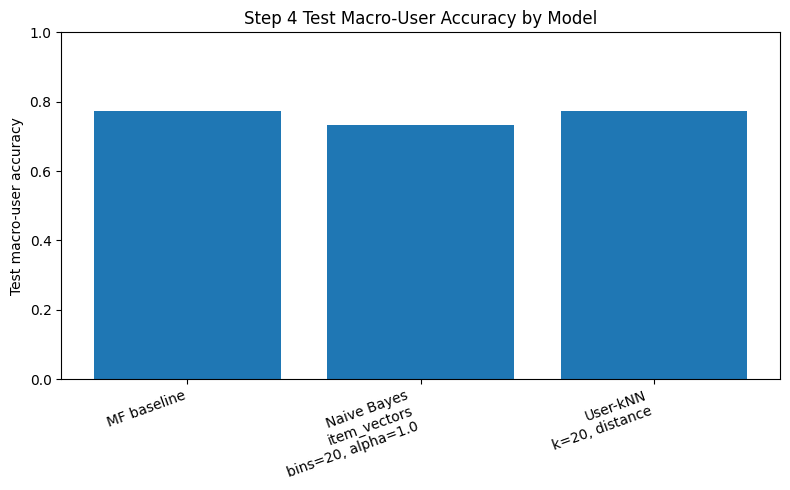

In [32]:
import matplotlib.pyplot as plt

def make_model_display_name(row):
    if row["model_family"] == "matrix_factorization":
        return "MF baseline"

    if row["model_family"] == "bayesian":
        return (
            "Naive Bayes\n"
            + str(row["feature_set"])
            + f"\nbins={int(row['n_bins'])}, alpha={row['alpha']}"
        )

    if row["model_family"] == "knn":
        return (
            "User-kNN\n"
            + f"k={int(row['k'])}, {row['weighting']}"
        )

    return str(row["model"])


test_model_comparison = final_model_comparison[
    final_model_comparison["split"] == "test"
].copy()

test_model_comparison["model_display"] = test_model_comparison.apply(
    make_model_display_name,
    axis=1,
)

plt.figure(figsize=(8, 5))
plt.bar(
    test_model_comparison["model_display"],
    test_model_comparison["macro_user_accuracy"],
)
plt.ylabel("Test macro-user accuracy")
plt.title("Step 4 Test Macro-User Accuracy by Model")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 5.6 Plot: test Brier score by model

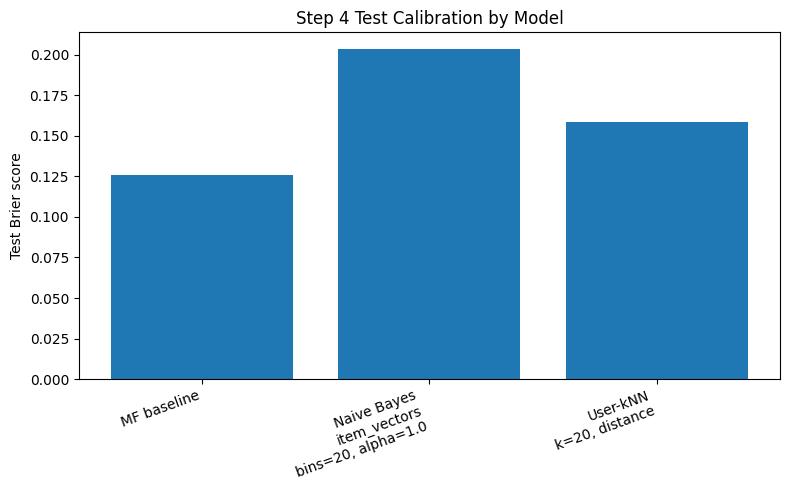

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(
    test_model_comparison["model_display"],
    test_model_comparison["brier_score"],
)
plt.ylabel("Test Brier score")
plt.title("Step 4 Test Calibration by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 5.7 Plot: kNN vs MF by train activity segment

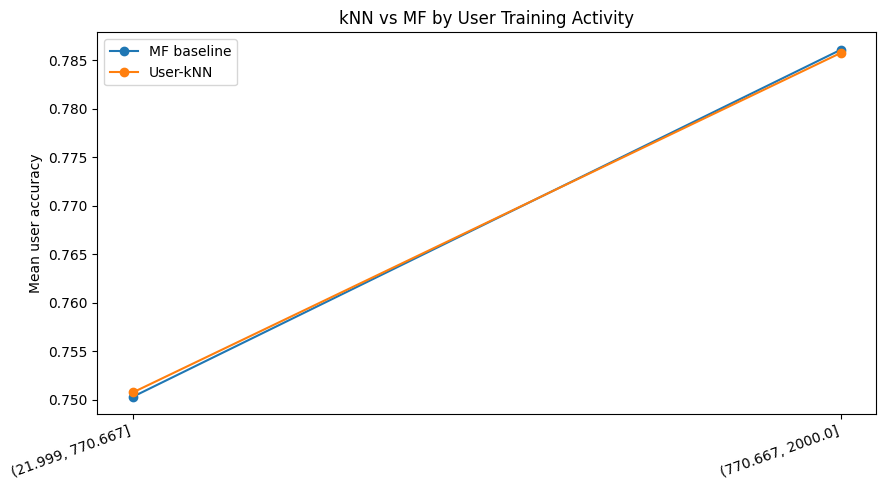

Block 5 complete.


In [ ]:
segment_plot = knn_vs_mf_evidence[
    knn_vs_mf_evidence["train_pair_segment"] != "overall"
].copy()

plt.figure(figsize=(9, 5))
plt.plot(
    segment_plot["train_pair_segment"],
    segment_plot["mf_user_accuracy"],
    marker="o",
    label="MF baseline",
)
plt.plot(
    segment_plot["train_pair_segment"],
    segment_plot["knn_user_accuracy"],
    marker="o",
    label="User-kNN",
)
plt.ylabel("Mean user accuracy")
plt.title("kNN vs MF by User Training Activity")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### 5.8 Outputs for reporting

In [35]:
compact_model_comparison = final_model_comparison[
    [
        "model",
        "model_family",
        "split",
        "feature_set",
        "k",
        "weighting",
        "n_bins",
        "alpha",
        "accuracy",
        "macro_user_accuracy",
        "auc",
        "brier_score",
        "log_loss",
    ]
].copy()

compact_model_comparison = compact_model_comparison.sort_values(
    ["split", "model_family"]
).reset_index(drop=True)

display(compact_model_comparison.round(6))


compact_bayes_feature_summary = bayes_feature_summary[
    [
        "feature_set",
        "n_bins",
        "alpha",
        "accuracy",
        "macro_user_accuracy",
        "auc",
        "brier_score",
        "log_loss",
    ]
].copy()

display(compact_bayes_feature_summary.round(6))


compact_knn_vs_mf_evidence = knn_vs_mf_evidence[
    [
        "train_pair_segment",
        "users",
        "mean_train_pairs",
        "mf_user_accuracy",
        "knn_user_accuracy",
        "knn_minus_mf",
        "share_users_where_knn_beats_mf",
    ]
].copy()

display(compact_knn_vs_mf_evidence.round(6))


compact_calibration_comparison = calibration_comparison[
    [
        "model",
        "model_family",
        "split",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
    ]
].copy()

display(compact_calibration_comparison.round(6))

,model,model_family,split,feature_set,k,weighting,n_bins,alpha,accuracy,macro_user_accuracy,auc,brier_score,log_loss
0,CategoricalNB,bayesian,test,item_vectors,NaN,NaN,20.0,1.0,0.783905,0.731856,0.879621,0.203749,2.663612
1,UserKNN,knn,test,user_embedding_neighbors,20.0,distance,NaN,NaN,0.814759,0.774071,0.865346,0.158871,2.842050
2,MF baseline,matrix_factorization,test,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,0.817919,0.774139,0.903074,0.126110,0.394358
3,CategoricalNB,bayesian,validation,item_vectors,NaN,NaN,20.0,1.0,0.768089,0.708656,0.864889,0.218159,2.738261
4,UserKNN,knn,validation,user_embedding_neighbors,20.0,distance,NaN,NaN,0.803289,0.756395,0.857074,0.166712,2.867745
5,MF baseline,matrix_factorization,validation,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,0.808433,0.757608,0.896024,0.131186,0.404075


,feature_set,n_bins,alpha,accuracy,macro_user_accuracy,auc,brier_score,log_loss
0,item_vectors,20,1.0,0.768089,0.708656,0.864889,0.218159,2.738261
1,item_difference,20,0.5,0.769524,0.707746,0.866306,0.215762,2.582390
2,user_vector,20,0.5,0.522493,0.467051,0.511107,0.249953,0.693053


,train_pair_segment,users,mean_train_pairs,mf_user_accuracy,knn_user_accuracy,knn_minus_mf,share_users_where_knn_beats_mf
0,"(21.999, 770.667]",1388,359.061239,0.750286,0.750734,0.000448,0.180115
1,"(770.667, 2000.0]",2776,1786.622118,0.786065,0.785739,-0.000326,0.372478
2,overall,4164,1310.768492,0.774139,0.774071,-0.000068,0.308357


,model,model_family,split,brier_score,log_loss,mean_forward_probability
0,MF baseline,matrix_factorization,test,0.126110,0.394358,0.753358
1,UserKNN,knn,test,0.158871,2.842050,0.809497
2,CategoricalNB,bayesian,test,0.203749,2.663612,0.783024
3,MF baseline,matrix_factorization,validation,0.131186,0.404075,0.741683
4,UserKNN,knn,validation,0.166712,2.867745,0.797404
5,CategoricalNB,bayesian,validation,0.218159,2.738261,0.767076


### Save Results

In [36]:
import joblib

step4_dir = Path("./results_step4")
step4_dir.mkdir(parents=True, exist_ok=True)

print("Step 4 output directory:", step4_dir)

Step 4 output directory: results_step4


In [37]:
compact_model_comparison = final_model_comparison[
    [
        "model",
        "model_family",
        "split",
        "feature_set",
        "k",
        "weighting",
        "metric",
        "n_bins",
        "alpha",
        "accuracy",
        "macro_user_accuracy",
        "median_user_accuracy",
        "auc",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
    ]
].copy()

compact_model_comparison = (
    compact_model_comparison
    .sort_values(["split", "model_family"])
    .reset_index(drop=True)
)


compact_bayes_feature_summary = bayes_feature_summary[
    [
        "feature_set",
        "n_bins",
        "alpha",
        "accuracy",
        "macro_user_accuracy",
        "auc",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
    ]
].copy()


compact_calibration_comparison = calibration_comparison[
    [
        "model",
        "model_family",
        "split",
        "feature_set",
        "k",
        "weighting",
        "n_bins",
        "alpha",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
    ]
].copy()


compact_knn_vs_mf_evidence = knn_vs_mf_evidence[
    [
        "train_pair_segment",
        "users",
        "mean_train_pairs",
        "median_train_pairs",
        "mf_user_accuracy",
        "knn_user_accuracy",
        "knn_minus_mf",
        "share_users_where_knn_beats_mf",
    ]
].copy()


step4_selection_summary = pd.DataFrame([
    {
        "model_family": "bayesian",
        "selected_model": "CategoricalNB",
        "selected_feature_set": best_bayes_feature_set,
        "selected_n_bins": best_bayes_n_bins,
        "selected_alpha": best_bayes_alpha,
        "selected_k": np.nan,
        "selected_weighting": np.nan,
        "metric": np.nan,
        "selection_metric": "validation_macro_user_accuracy",
        "validation_macro_user_accuracy": float(best_bayes_selection["validation_macro_user_accuracy"].iloc[0]),
        "validation_accuracy": float(best_bayes_selection["validation_accuracy"].iloc[0]),
        "validation_auc": float(best_bayes_selection["validation_auc"].iloc[0]),
        "validation_brier_score": float(best_bayes_selection["validation_brier_score"].iloc[0]),
        "validation_log_loss": float(best_bayes_selection["validation_log_loss"].iloc[0]),
    },
    {
        "model_family": "knn",
        "selected_model": "UserKNN",
        "selected_feature_set": "user_embedding_neighbors",
        "selected_n_bins": np.nan,
        "selected_alpha": np.nan,
        "selected_k": best_knn_k,
        "selected_weighting": best_knn_weighting,
        "metric": knn_metric,
        "selection_metric": "validation_macro_user_accuracy",
        "validation_macro_user_accuracy": float(best_knn_selection["validation_macro_user_accuracy"].iloc[0]),
        "validation_accuracy": float(best_knn_selection["validation_accuracy"].iloc[0]),
        "validation_auc": float(best_knn_selection["validation_auc"].iloc[0]),
        "validation_brier_score": float(best_knn_selection["validation_brier_score"].iloc[0]),
        "validation_log_loss": float(best_knn_selection["validation_log_loss"].iloc[0]),
    },
])

display(compact_model_comparison.round(6))
display(compact_bayes_feature_summary.round(6))
display(compact_calibration_comparison.round(6))
display(compact_knn_vs_mf_evidence.round(6))
display(step4_selection_summary.round(6))

,model,model_family,split,feature_set,k,weighting,metric,n_bins,alpha,accuracy,macro_user_accuracy,median_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,CategoricalNB,bayesian,test,item_vectors,NaN,NaN,NaN,20.0,1.0,0.783905,0.731856,0.781250,0.879621,0.203749,2.663612,0.783024
1,UserKNN,knn,test,user_embedding_neighbors,20.0,distance,cosine,NaN,NaN,0.814759,0.774071,0.824158,0.865346,0.158871,2.842050,0.809497
2,MF baseline,matrix_factorization,test,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,NaN,0.817919,0.774139,0.821094,0.903074,0.126110,0.394358,0.753358
3,CategoricalNB,bayesian,validation,item_vectors,NaN,NaN,NaN,20.0,1.0,0.768089,0.708656,0.750000,0.864889,0.218159,2.738261,0.767076
4,UserKNN,knn,validation,user_embedding_neighbors,20.0,distance,cosine,NaN,NaN,0.803289,0.756395,0.800000,0.857074,0.166712,2.867745,0.797404
5,MF baseline,matrix_factorization,validation,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,NaN,0.808433,0.757608,0.802437,0.896024,0.131186,0.404075,0.741683


,feature_set,n_bins,alpha,accuracy,macro_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,item_vectors,20,1.0,0.768089,0.708656,0.864889,0.218159,2.738261,0.767076
1,item_difference,20,0.5,0.769524,0.707746,0.866306,0.215762,2.582390,0.768846
2,user_vector,20,0.5,0.522493,0.467051,0.511107,0.249953,0.693053,0.500143


,model,model_family,split,feature_set,k,weighting,n_bins,alpha,brier_score,log_loss,mean_forward_probability
0,MF baseline,matrix_factorization,test,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,0.126110,0.394358,0.753358
1,UserKNN,knn,test,user_embedding_neighbors,20.0,distance,NaN,NaN,0.158871,2.842050,0.809497
2,CategoricalNB,bayesian,test,item_vectors,NaN,NaN,20.0,1.0,0.203749,2.663612,0.783024
3,MF baseline,matrix_factorization,validation,p_u_dot_q_diff_plus_bias_diff,NaN,NaN,NaN,NaN,0.131186,0.404075,0.741683
4,UserKNN,knn,validation,user_embedding_neighbors,20.0,distance,NaN,NaN,0.166712,2.867745,0.797404
5,CategoricalNB,bayesian,validation,item_vectors,NaN,NaN,20.0,1.0,0.218159,2.738261,0.767076


,train_pair_segment,users,mean_train_pairs,median_train_pairs,mf_user_accuracy,knn_user_accuracy,knn_minus_mf,share_users_where_knn_beats_mf
0,"(21.999, 770.667]",1388,359.061239,319.5,0.750286,0.750734,0.000448,0.180115
1,"(770.667, 2000.0]",2776,1786.622118,2000.0,0.786065,0.785739,-0.000326,0.372478
2,overall,4164,1310.768492,1716.0,0.774139,0.774071,-0.000068,0.308357


,model_family,selected_model,selected_feature_set,selected_n_bins,selected_alpha,selected_k,selected_weighting,metric,selection_metric,validation_macro_user_accuracy,validation_accuracy,validation_auc,validation_brier_score,validation_log_loss
0,bayesian,CategoricalNB,item_vectors,20.0,1.0,NaN,NaN,NaN,validation_macro_user_accuracy,0.708656,0.768089,0.864889,0.218159,2.738261
1,knn,UserKNN,user_embedding_neighbors,NaN,NaN,20.0,distance,cosine,validation_macro_user_accuracy,0.756395,0.803289,0.857074,0.166712,2.867745


In [ ]:
tables_to_save = {
    "final_model_comparison.parquet": final_model_comparison,
    "compact_model_comparison.parquet": compact_model_comparison,
    "bayes_validation_results.parquet": bayes_validation_results,
    "bayes_feature_summary.parquet": compact_bayes_feature_summary,
    "knn_validation_results.parquet": knn_validation_results,
    "calibration_comparison.parquet": compact_calibration_comparison,
    "bayes_vs_mf_calibration.parquet": bayes_vs_mf_calibration,
    "knn_vs_mf_evidence.parquet": compact_knn_vs_mf_evidence,
    "step4_selection_summary.parquet": step4_selection_summary,
}

for filename, table in tables_to_save.items():
    table.to_parquet(step4_dir / filename, index=False)

Saved compact Step 4 result tables.


In [39]:
best_bayesian_artifact = {
    "model": best_bayes_model,
    "discretizer": best_bayes_discretizer,
    "feature_set": best_bayes_feature_set,
    "n_bins": int(best_bayes_n_bins),
    "alpha": float(best_bayes_alpha),
    "bin_strategy": bayes_bin_strategy,
    "selection_metric": "validation_macro_user_accuracy",
}

joblib.dump(
    best_bayesian_artifact,
    step4_dir / "best_bayesian_categorical_nb.joblib",
)

print("Saved selected Bayesian model artifact.")

Saved selected Bayesian model artifact.


In [40]:
best_knn_neighbor_indices = user_neighbor_indices[:, :best_knn_k]
best_knn_neighbor_distances = user_neighbor_distances[:, :best_knn_k]

np.save(
    step4_dir / "best_user_knn_neighbor_indices.npy",
    best_knn_neighbor_indices,
)

np.save(
    step4_dir / "best_user_knn_neighbor_distances.npy",
    best_knn_neighbor_distances,
)

print("Saved selected kNN neighbor arrays.")
print("Neighbor indices shape:", best_knn_neighbor_indices.shape)
print("Neighbor distances shape:", best_knn_neighbor_distances.shape)

Saved selected kNN neighbor arrays.
Neighbor indices shape: (4722, 20)
Neighbor distances shape: (4722, 20)


In [41]:
def make_json_safe(value):
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        return float(value)

    if isinstance(value, (np.ndarray,)):
        return value.tolist()

    if pd.isna(value):
        return None

    return value


step4_config = {
    "random_seed": int(random_seed),

    "input_artifacts": {
        "step1_dir": str(step1_dir),
        "step2_dir": str(step2_dir),
        "train_pairs": "train_pairs.parquet",
        "validation_pairs": "validation_pairs.parquet",
        "test_pairs": "test_pairs.parquet",
        "user_embeddings": "user_embeddings_p_u.npy",
        "item_embeddings": "item_embeddings_q_i.npy",
        "item_bias": "item_bias.npy",
    },

    "evaluation": {
        "validation_pairs": int(len(val_pairs_idx)),
        "test_pairs": int(len(test_pairs_idx)),
        "metric_used_for_selection": "validation_macro_user_accuracy",
        "accuracy_definition": "original pair is correct if predicted P(pos_item > neg_item) > 0.5",
        "probabilistic_metrics": "AUC, Brier score, and log loss are computed using symmetric directional rows",
    },

    "mf_baseline": {
        "score_formula": "p_u dot (q_pos - q_neg) + bias_pos - bias_neg",
        "uses_full_validation": True,
        "uses_full_test": True,
    },

    "bayesian": {
        "model": "CategoricalNB",
        "discretizer": "KBinsDiscretizer",
        "train_direction_policy": "random_swap",
        "feature_sets_tested": bayes_feature_sets,
        "n_bins_candidates": bayes_n_bins_candidates,
        "alpha_candidates": bayes_alpha_candidates,
        "bin_strategy": bayes_bin_strategy,
        "discretizer_fit_sample_n": int(bayes_discretizer_fit_sample_n),
        "batch_size": int(bayes_batch_size),
        "selected_feature_set": best_bayes_feature_set,
        "selected_n_bins": int(best_bayes_n_bins),
        "selected_alpha": float(best_bayes_alpha),
    },

    "knn": {
        "model": "UserKNN",
        "neighbor_space": "user_embeddings",
        "metric": knn_metric,
        "k_candidates": knn_k_candidates,
        "weighting_candidates": knn_weighting_candidates,
        "selected_k": int(best_knn_k),
        "selected_weighting": best_knn_weighting,
        "batch_size": int(knn_batch_size),
        "weight_epsilon": float(knn_weight_epsilon),
    },

    "saved_files": sorted(list(tables_to_save.keys()) + [
        "best_bayesian_categorical_nb.joblib",
        "best_user_knn_neighbor_indices.npy",
        "best_user_knn_neighbor_distances.npy",
        "step4_config.json",
    ]),
}

step4_config = {
    key: value
    for key, value in step4_config.items()
}

with open(step4_dir / "step4_config.json", "w") as f:
    json.dump(step4_config, f, indent=2, default=make_json_safe)

print("Saved Step 4 config.")

Saved Step 4 config.


In [42]:
saved_file_summary = []

for path in sorted(step4_dir.iterdir()):
    if path.is_file():
        saved_file_summary.append({
            "filename": path.name,
            "size_mb": round(path.stat().st_size / (1024 ** 2), 4),
        })

saved_file_summary = pd.DataFrame(saved_file_summary)

display(saved_file_summary)

print("Block 6 complete. Step 4 necessary results are saved.")

,filename,size_mb
0,bayes_feature_summary.parquet,0.0058
1,bayes_validation_results.parquet,0.0128
2,bayes_vs_mf_calibration.parquet,0.0033
3,best_bayesian_categorical_nb.joblib,0.1168
4,best_user_knn_neighbor_distances.npy,0.3604
5,best_user_knn_neighbor_indices.npy,0.7206
6,calibration_comparison.parquet,0.0068
7,compact_model_comparison.parquet,0.0097
8,final_model_comparison.parquet,0.0114
9,knn_validation_results.parquet,0.0137


Block 6 complete. Step 4 necessary results are saved.
